## 5. Plot Water Consumption Delta (Boston Example)

This notebook shows how water consumption differences were plotted

In [1]:
import os, shutil, cv2,datetime, copy
import matplotlib.pyplot as plt
os.chdir('/home/klimenko/CoolingMachines/explore_flir')
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
from PIL import Image
import time
import numpy as np
from scipy.ndimage import zoom
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image,ImageFile
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch.nn as nn
import pandas as pd

/home/klimenko/CoolingMachines/explore_flir
Couldn't import dot_parser, loading of dot files will not be possible.


In [12]:
result = pd.read_csv('dataset/BOSTON_FLIR_DATASET/all.csv')
result = result.dropna(subset=['species'])
result['species'] = result['species'].replace('Ulmus Americana', 'Ulmus')
print(len(result))

478


In [13]:
set(result['species'])

{'Liquidambar', 'Liriodendron', 'Platanus', 'Quercus', 'Ulmus'}

In [6]:
# Function to map species to daily water consumption
def get_water_consumption(species):
    water_consumption = {
        'Liquidambar': 19.8,
        'Liriodendron': 87,
        'Platanus': 175,
        'Quercus': 46,
        'Ulmus': 21.2,
    }
    return water_consumption.get(species, np.nan)

# Create a new column 'water_consumption'
result['water_consumption'] = result['species'].apply(get_water_consumption)
result
result = result.dropna(subset=['water_consumption'])
result['efficiency'] = result['temperature_delta'] / result['water_consumption']
result = result.dropna(subset=['efficiency'])
print(len(result))

494


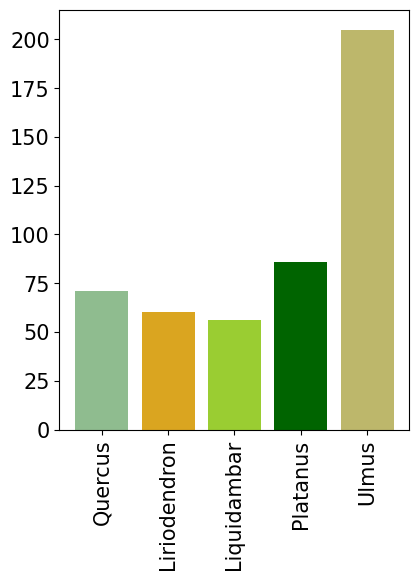

In [14]:
import matplotlib.pyplot as plt
from collections import Counter

# Sample list of strings
string_list = list(result['species'])

# Count the frequency of each string
string_counts = Counter(string_list)

# Prepare data for plotting
labels = list(string_counts.keys())
values = list(string_counts.values())

# Custom color dictionary for species
color_dict = {
    'Liquidambar': 'yellowgreen',     # green
    'Liriodendron': 'goldenrod',     # orange
    'Platanus': 'darkgreen',    # blue
    'Quercus': 'darkseagreen',     # red
    'Ulmus': 'darkkhaki',     # purple
}
# Assign colors to each bar, default to gray if species not in dictionary
colors = [color_dict.get(label, '#7f7f7f') for label in labels]


# Create the bar chart with custom colors
fig = plt.figure(figsize=(5, 7))
ax = fig.add_axes([0.20, 0.30, 0.70, 0.60])
ax.bar(labels, values, color=colors)
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)
plt.xticks(rotation=90)
plt.show()
fig.savefig('_species_management_and_viz/export/species_count/boston.png')

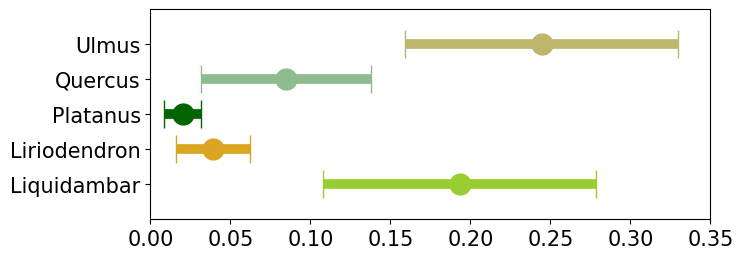

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
df = result

# Group by species and compute mean and std dev
species_mean_temp_delta = df.groupby('species')['efficiency'].mean()
species_std_temp_delta = df.groupby('species')['efficiency'].std()

# Create fixed-size figure (export size)
fig = plt.figure(figsize=(8, 3))
ax = fig.add_axes([0.25, 0.20, 0.70, 0.70])  # Adjust left to allow long labels
for i, species in enumerate(species_mean_temp_delta.index):
    color = color_dict.get(species, '#7f7f7f')
    ax.errorbar(species_mean_temp_delta[species], species,xerr=species_std_temp_delta[species],fmt='o',
        color=color,ecolor=color,elinewidth=7,capsize=10,linestyle='None',markersize=15)
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)
#ax.set_xlabel('Temperature Delta, deg C')
#ax.set_ylabel('Genera')
ax.set_ylim(-1, len(species_mean_temp_delta))
ax.set_xlim(-0.0, 0.35)
fig.savefig('_species_management_and_viz/export/shade/bos_efficiency_test.png')